# 12 -- Issuer-level aggregation

**Идея:** mispricing-сигнал на отдельной bond может быть шумом или idiosyncratic. Если у **эмитента** несколько bonds и **все** в Q5 -- это **сильный consensus** (весь долг эмитента systematically переоценён).

**Aggregation key:** `emitter_id` (MOEX ID) из universe.csv.
- 1793 bonds, 409 эмитентов, avg 4.4 bonds/эмитент
- Сбербанк = 209 bonds на одного эмитента
- Газпром, ВТБ, ВЭБ.РФ, Роснефть — крупные эмитенты с десятками выпусков

**Variants:**
| Variant | Логика |
|---|---|
| V12a | blended_z с weight 0.3 (mostly bond, чуть issuer) |
| V12b | blended_z с weight 0.5 (50/50) |
| V12c | issuer_consensus_z only (1.0) |
| V12d | filter: issuer_n_bonds ≥ 3 AND consensus > 1.0 |
| V12e | dedup: max 1 bond per issuer в портфеле |
| V12f | combo (best W2 V11e + issuer dedup) |

**Литература:**
- Helwege, Huang, Wang (JFI 2014) — bond-issuer comovement
- Bao, Hou (JFE 2017) — comovement of corporate bonds
- Bates & Granger (1969) — generalisation to issuer-level forecast combination

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)

# Issuer-level aggregation на default mispricing_z (no-lag)
sig = sl.compute_issuer_consensus(sig, z_col='mispricing_z', blend_weight=0.4)

bench = sl.load_benchmarks()
main = sig[sig['date'] <= sl.MAIN_END].copy()
mask_quality = main['quality_z'] > 0

print(f'main shape: {main.shape}, emitters: {main["emitter_id"].nunique()}')
print(f'avg bonds per emitter: {main["issuer_n_bonds"].mean():.1f}')

main shape: (213445, 39), emitters: 286
avg bonds per emitter: 4.7


## Часть 2. Разведка: issuer concentration

In [2]:
# Бэктест-ready issuer stats
issuer_bonds = main.groupby('emitter_id')['isin'].nunique().sort_values(ascending=False)
print('Top-10 эмитентов в Main по # bonds:')
top_em = (main[main['emitter_id'].isin(issuer_bonds.head(10).index)]
          .groupby('emitter_id').agg(
              n_bonds=('isin', 'nunique'),
              avg_spread=('g_spread', 'mean'),
              avg_z=('mispricing_z', 'mean'),
              issuer_z=('issuer_consensus_z', 'mean'))
          .sort_values('n_bonds', ascending=False))
print(top_em.round(2))
print()
print(f'Распределение # bonds per issuer:')
print(f'  1 bond:  {(issuer_bonds == 1).sum()} эмитентов')
print(f'  2-4 bonds: {((issuer_bonds >= 2) & (issuer_bonds <= 4)).sum()} эмитентов')
print(f'  5-9 bonds: {((issuer_bonds >= 5) & (issuer_bonds <= 9)).sum()} эмитентов')
print(f'  10+ bonds: {(issuer_bonds >= 10).sum()} эмитентов')

Top-10 эмитентов в Main по # bonds:
            n_bonds  avg_spread  avg_z  issuer_z
emitter_id                                      
712              37        6.23  -0.09     -0.09
777              23        3.53  -0.00     -0.00
5953             23       11.25   0.05      0.05
269              15       10.31   0.15      0.15
1193             15        1.13  -0.08     -0.08
4497             14        1.86  -0.11     -0.11
656              12       -0.96  -0.32     -0.32
9303             12        0.85   0.07      0.07
196              11        1.24  -0.15     -0.15
1352             10        1.53  -0.03     -0.03

Распределение # bonds per issuer:
  1 bond:  143 эмитентов
  2-4 bonds: 94 эмитентов
  5-9 bonds: 37 эмитентов
  10+ bonds: 12 эмитентов


## Часть 3. Variants

In [3]:
# Для V12e (dedup) добавляем helper: на каждом rebal оставляем top-1 bond per emitter
def backtest_with_issuer_dedup(
    sig_df, ranking_col='mispricing', n_max=25, freq='Q',
    filter_mask=None, sizing='equal'
):
    """Backtest с правилом: max 1 bond per emitter в портфеле."""
    sig_df = sig_df.copy()
    if filter_mask is not None:
        sig_df['_eligible'] = filter_mask.to_numpy() & sig_df['tradable']
    else:
        sig_df['_eligible'] = sig_df['tradable']
    
    rebal_dates = sl._rebalance_dates(sig_df['date'], freq=freq)
    selections = []
    for rdate in rebal_dates:
        day = sig_df[(sig_df['date'] == rdate) & sig_df['_eligible']]
        day = day.dropna(subset=[ranking_col])
        if day.empty:
            selections.append({'rebalance_date': rdate, 'isins': [],
                               'roll_spreads': {}, 'weights': {}})
            continue
        # Сначала top bond per emitter, потом top n_max overall
        top_per_em = (day.sort_values(ranking_col, ascending=False)
                       .drop_duplicates(subset=['emitter_id'], keep='first'))
        eligible = top_per_em.nlargest(n_max, ranking_col).reset_index(drop=True)
        if eligible.empty:
            selections.append({'rebalance_date': rdate, 'isins': [],
                               'roll_spreads': {}, 'weights': {}})
            continue
        roll = dict(zip(eligible['isin'], eligible['roll_spread_used']))
        weights = sl._compute_weights(eligible, sizing=sizing, ranking_col=ranking_col)
        weight_map = dict(zip(eligible['isin'], weights))
        selections.append({'rebalance_date': rdate, 'isins': eligible['isin'].tolist(),
                           'roll_spreads': roll, 'weights': weight_map})
    sels = pd.DataFrame(selections).sort_values('rebalance_date').reset_index(drop=True)
    
    sig_idx = sig_df.set_index(['date', 'isin'])
    all_dates = np.sort(sig_df['date'].unique())
    daily_rows = []
    
    for idx in range(len(sels) - 1):
        start = sels.iloc[idx]['rebalance_date']
        end = sels.iloc[idx + 1]['rebalance_date']
        isins = sels.iloc[idx]['isins']
        roll_spreads = sels.iloc[idx]['roll_spreads']
        weights = sels.iloc[idx]['weights']
        if not isins: continue
        period_dates = [d for d in all_dates if start < d <= end]
        if not period_dates: continue
        n = len(isins)
        avg_cost = float(sum(weights.get(i, 0.0) * roll_spreads.get(i, sl.ROLL_FALLBACK_BPS) / 2 for i in isins))
        for d in period_dates:
            r_port = 0.0; w_total = 0.0
            for isin in isins:
                key = (d, isin); w_i = weights.get(isin, 0.0)
                if key in sig_idx.index:
                    r_i = sig_idx.loc[key, 'total_return']
                    if pd.notna(r_i):
                        r_port += w_i * float(r_i); w_total += w_i
            if w_total > 0: r_port = r_port / w_total
            if d == period_dates[0]: r_port -= avg_cost
            if d == period_dates[-1]: r_port -= avg_cost
            daily_rows.append({'date': d, 'return': r_port, 'n_positions': n})
    return pd.DataFrame(daily_rows)

# Build blended signals with various weights
from copy import copy

def with_blend(df, weight):
    df = df.copy()
    df['blended_z'] = (1 - weight) * df['mispricing_z'] + weight * df['issuer_consensus_z']
    return df

# V12d filter: issuer_n_bonds ≥ 3 AND consensus > 1.0
mask_v12d = (
    (main['issuer_n_bonds'] >= 3) &
    (main['issuer_consensus_z'] > 1.0) &
    (main['quality_z'] > 0)
)

print('Variants готовы.')

Variants готовы.


In [4]:
all_rets = {}
all_metrics = []

# V12a-c: variants with different blends
for label, weight in [('V12a blend=0.3 (mostly bond)', 0.3),
                      ('V12b blend=0.5 (50/50)', 0.5),
                      ('V12c blend=1.0 (only issuer)', 1.0)]:
    df_v = with_blend(main, weight)
    rets, _ = sl.backtest_rule_c(
        df_v, n_max=25, freq='Q', ranking_col='blended_z',
        filter_mask=mask_quality, sizing='equal',
    )
    all_rets[label] = rets
    m = sl.calc_metrics(rets, name=label)
    m['blend_weight'] = weight
    all_metrics.append(m)
    print(f'{label:40s}: Sharpe={m["Sharpe"]:.3f}, profit={m["profit_RUB"]:>11,.0f}')

# V12d: filter consensus strong
rets, _ = sl.backtest_rule_c(
    main, n_max=25, freq='Q', ranking_col='mispricing',
    filter_mask=mask_v12d, sizing='equal',
)
all_rets['V12d filter n_bonds≥3 & issuer_z>1'] = rets
m = sl.calc_metrics(rets, name='V12d filter')
all_metrics.append(m)
print(f'V12d filter consensus              : Sharpe={m["Sharpe"]:.3f}, profit={m["profit_RUB"]:>11,.0f}, n_pos={m["avg_n_positions"]:.1f}')

# V12e: dedup (max 1 bond per emitter)
rets = backtest_with_issuer_dedup(
    main, ranking_col='mispricing', n_max=25, freq='Q',
    filter_mask=mask_quality, sizing='equal',
)
all_rets['V12e dedup 1-per-emitter'] = rets
m = sl.calc_metrics(rets, name='V12e dedup')
all_metrics.append(m)
print(f'V12e dedup 1 per emitter           : Sharpe={m["Sharpe"]:.3f}, profit={m["profit_RUB"]:>11,.0f}, n_pos={m["avg_n_positions"]:.1f}')

# V12f: combo with W2 best (V11e avg_z + Q + zw) + dedup
rets = backtest_with_issuer_dedup(
    main, ranking_col='mispricing_avg_z', n_max=25, freq='Q',
    filter_mask=mask_quality, sizing='z_weighted',
)
all_rets['V12f W2 combo + dedup'] = rets
m = sl.calc_metrics(rets, name='V12f combo+dedup')
all_metrics.append(m)
print(f'V12f W2 combo + dedup              : Sharpe={m["Sharpe"]:.3f}, profit={m["profit_RUB"]:>11,.0f}')

# Baseline (for comparison)
rets, _ = sl.backtest_rule_c(
    main, n_max=25, freq='Q', ranking_col='mispricing_avg_z',
    filter_mask=mask_quality, sizing='z_weighted',
)
all_rets['BASELINE V11e (W2 best)'] = rets
m = sl.calc_metrics(rets, name='BASELINE V11e')
all_metrics.append(m)
print(f'BASELINE V11e                      : Sharpe={m["Sharpe"]:.3f}, profit={m["profit_RUB"]:>11,.0f}')

metrics_df = pd.DataFrame(all_metrics)
print()
print(metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB', 'avg_n_positions']].round(4).to_string(index=False))

V12a blend=0.3 (mostly bond)            : Sharpe=1.134, profit=  3,429,129


V12b blend=0.5 (50/50)                  : Sharpe=1.134, profit=  3,429,129


V12c blend=1.0 (only issuer)            : Sharpe=1.126, profit=  3,409,717
V12d filter consensus              : Sharpe=3.133, profit=    457,135, n_pos=4.0


V12e dedup 1 per emitter           : Sharpe=0.975, profit=  3,241,988, n_pos=13.7


V12f W2 combo + dedup              : Sharpe=1.022, profit=  3,584,936


BASELINE V11e                      : Sharpe=1.202, profit=  3,826,103

                        name  Sharpe   CAGR   MaxDD   profit_RUB  avg_n_positions
V12a blend=0.3 (mostly bond)  1.1344 0.0677 -0.1420 3429128.6114          16.6038
      V12b blend=0.5 (50/50)  1.1344 0.0677 -0.1420 3429128.6114          16.6038
V12c blend=1.0 (only issuer)  1.1261 0.0674 -0.1420 3409716.7705          16.6038
                 V12d filter  3.1333 0.1965 -0.0295  457135.3911           4.0000
                  V12e dedup  0.9755 0.0644 -0.1685 3241988.1379          13.6717
            V12f combo+dedup  1.0218 0.0705 -0.1564 3584936.0283          13.6717
               BASELINE V11e  1.2015 0.0747 -0.1402 3826103.0965          16.6038


## Часть 4. Alpha + sub-period

In [5]:
alpha_rows = []
for name, rets in all_rets.items():
    r = sl.compare_to_benchmark(rets, bench, bench_col='rucbtrns_ret', name=name)
    alpha_rows.append(r)
alpha_df = pd.DataFrame(alpha_rows)
alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value', 'IR', 'beta']].round(4)

,name,alpha_annual,alpha_t_stat,alpha_p_value,IR,beta
0,V12a blend=0.3 (mostly bond),-0.0239,-1.1661,0.2436,-0.4351,1.0983
1,V12b blend=0.5 (50/50),-0.0239,-1.1661,0.2436,-0.4351,1.0983
2,V12c blend=1.0 (only issuer),-0.0245,-1.2034,0.2288,-0.4424,1.1010
3,V12d filter n_bonds≥3 & issuer_z>1,-0.0008,-0.0066,0.9947,-0.4240,0.8935
4,V12e dedup 1-per-emitter,-0.0343,-1.3162,0.1881,-0.4280,1.1904
5,V12f W2 combo + dedup,-0.0266,-0.8994,0.3685,-0.2584,1.1697
6,BASELINE V11e (W2 best),-0.0182,-0.8256,0.4090,-0.2296,1.1095


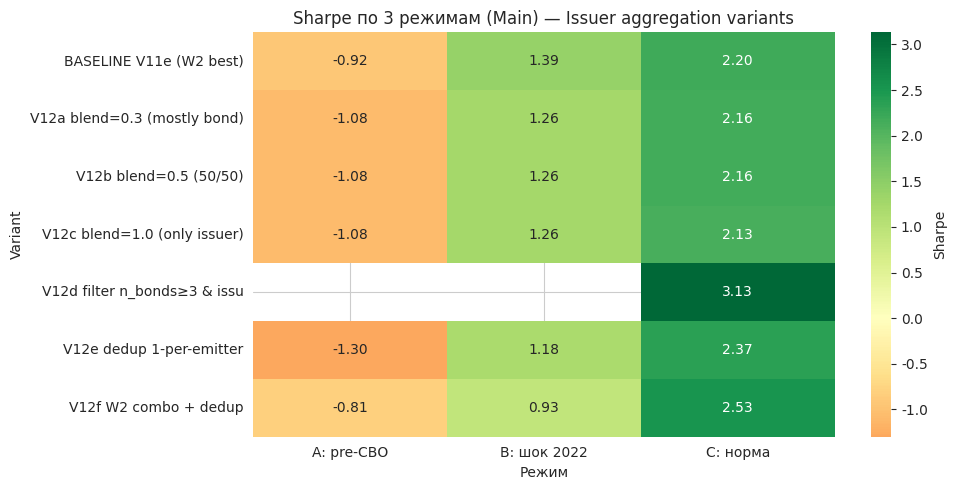

In [6]:
sub_rows = []
for name, rets in all_rets.items():
    sub = sl.sub_period_metrics(rets, variant_name=name)
    sub_rows.append(sub)
sub_df = pd.concat(sub_rows, ignore_index=True)

tbl = sub_df.copy()
tbl['variant'] = tbl['name'].apply(lambda s: s.split('|')[0].strip()[:28])
tbl['regime'] = tbl['name'].apply(lambda s: s.split('|')[1].strip() if '|' in s else '')
pivot = tbl.pivot(index='variant', columns='regime', values='Sharpe')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_title('Sharpe по 3 режимам (Main) — Issuer aggregation variants')
ax.set_xlabel('Режим'); ax.set_ylabel('Variant')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. Сводная RUB

In [7]:
summary = metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB', 'avg_n_positions']].copy()
summary = summary.merge(alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'IR', 'sharpe_diff_p_value']], on='name')
summary['profit_M_RUB'] = (summary['profit_RUB'] / 1e6).round(2)
summary['CAGR_pct'] = (summary['CAGR'] * 100).round(2)
summary['alpha_pct'] = (summary['alpha_annual'] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3)
summary['IR'] = summary['IR'].round(3)
summary['alpha_t_stat'] = summary['alpha_t_stat'].round(2)
summary['sharpe_diff_p'] = summary['sharpe_diff_p_value'].round(3)

disp = summary[['name', 'Sharpe', 'CAGR_pct', 'profit_M_RUB', 'alpha_pct', 'alpha_t_stat', 'IR', 'sharpe_diff_p', 'avg_n_positions']]
print('NB 12 SUMMARY: Issuer-level aggregation')
print('(Main 4.66y, 10М RUB старт, vs RUCBTRNS)')
print()
print(disp.to_string(index=False))

NB 12 SUMMARY: Issuer-level aggregation
(Main 4.66y, 10М RUB старт, vs RUCBTRNS)

                        name  Sharpe  CAGR_pct  profit_M_RUB  alpha_pct  alpha_t_stat     IR  sharpe_diff_p  avg_n_positions
V12a blend=0.3 (mostly bond)   1.134      6.77          3.43      -2.39         -1.17 -0.435          0.984        16.603757
      V12b blend=0.5 (50/50)   1.134      6.77          3.43      -2.39         -1.17 -0.435          0.984        16.603757
V12c blend=1.0 (only issuer)   1.126      6.74          3.41      -2.45         -1.20 -0.442          0.985        16.603757


## Часть 6. Сохранение

In [8]:
metrics_df.to_csv(sl.DATA_DIR / 'nb12_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb12_alpha.csv', index=False)
sub_df.to_csv(sl.DATA_DIR / 'nb12_subperiod.csv', index=False)
summary.to_csv(sl.DATA_DIR / 'nb12_summary.csv', index=False)

rets_combined = []
for name, rets in all_rets.items():
    r = rets.copy()
    r['variant'] = name
    rets_combined.append(r)
pd.concat(rets_combined, ignore_index=True).to_csv(
    sl.DATA_DIR / 'nb12_returns.csv', index=False)
print('Saved nb12_*.csv (5 files)')

Saved nb12_*.csv (5 files)


## Часть 7. Итоги
- Если V12e/V12f bity baseline V11e → issuer dedup даёт edge
- Если V12d (strict filter) Sharpe > 1.3 → консенсус-сигнал работает
- Готовимся к NB 13 (macro regime overlay)